IMAGE PROCESSING
- [] Grayscale
- [] Filtering
- [] Threshold

In [8]:
import cv2
import matplotlib.pyplot as plt

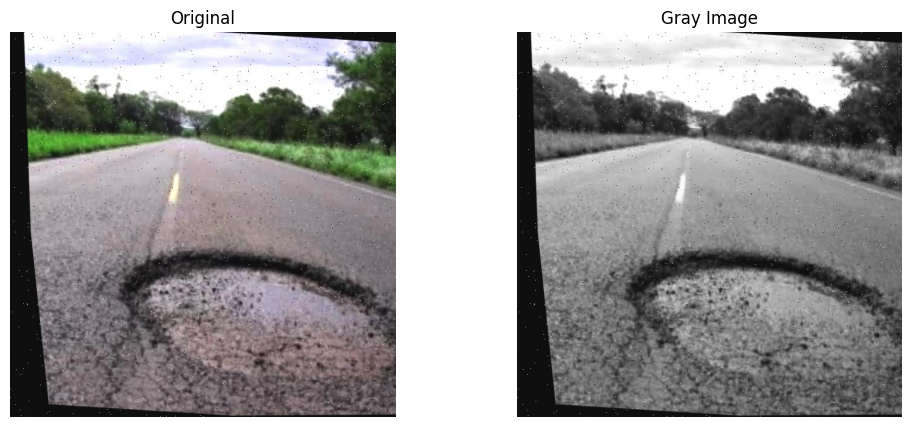

In [9]:
img = cv2.imread('train_369.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display images using matplotlib (works in notebooks)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Gray Image')
plt.axis('off')

plt.show()

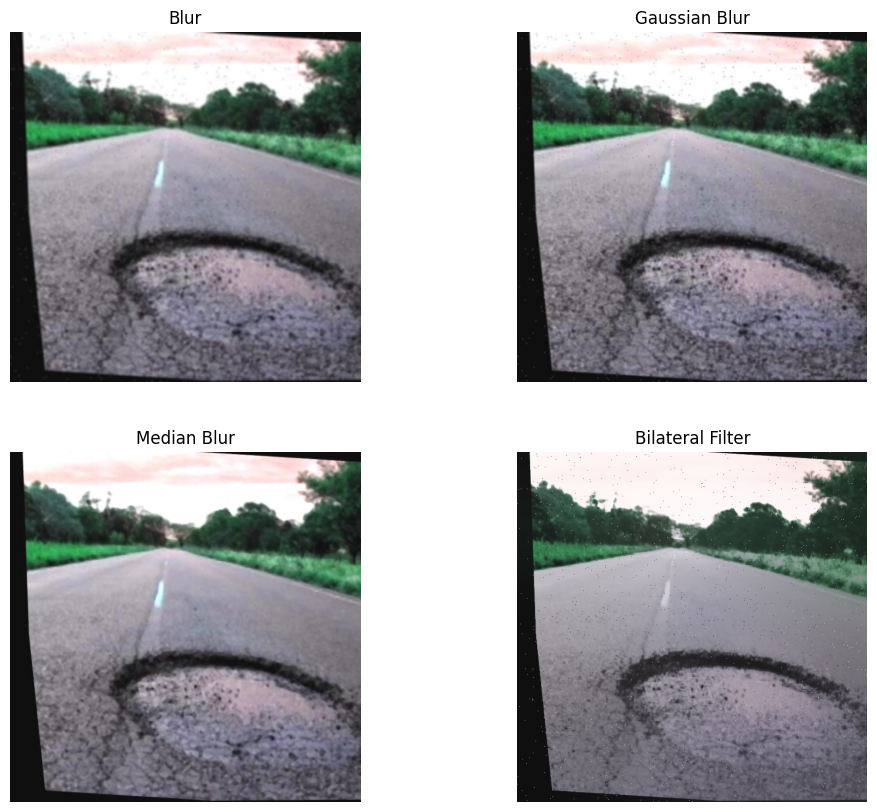

In [10]:
# Filtering

img = cv2.imread('train_369.jpg')

# 4 types of filtering : blur, GaussianBlur, medianBlur, bilateralFilter
blur = cv2.blur(img, (5,5)) # (5,5) -> kernel size
GaussianBlur = cv2.GaussianBlur(img, (5,5), 0) # 0 -> sigmaX
# for gaussian formula, let python do the calculation :)
medianBlur = cv2.medianBlur(img, 5) # 5 -> 5 x 5 sama aja kaya (5,5)
# diatas. Harus ganjil valuenya supaya bisa dapat median value
bilateralFilter = cv2.bilateralFilter(img, 0, 75, 75)
# d -> diameter => kernel size
# sigmaColor -> seberapa cepat pengaruh warna menurun
# biasanya low value aja 10-30 supaya warna yang mirip aja yang dhitung
# sigmaSpace -> seberapa cepat pengaruh jarak menurun
# biasanya kalau mau lokal di value 1-20, kalau 50 keatas ibaratnya jarak yang jauhpun pixelnya jadi perhitungan ke kalkulasi

# Display filtered images
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(blur)
plt.title('Blur')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(GaussianBlur)
plt.title('Gaussian Blur')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(medianBlur)
plt.title('Median Blur')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(bilateralFilter)
plt.title('Bilateral Filter')
plt.axis('off')
plt.show()

Otsu's threshold value: 127.0


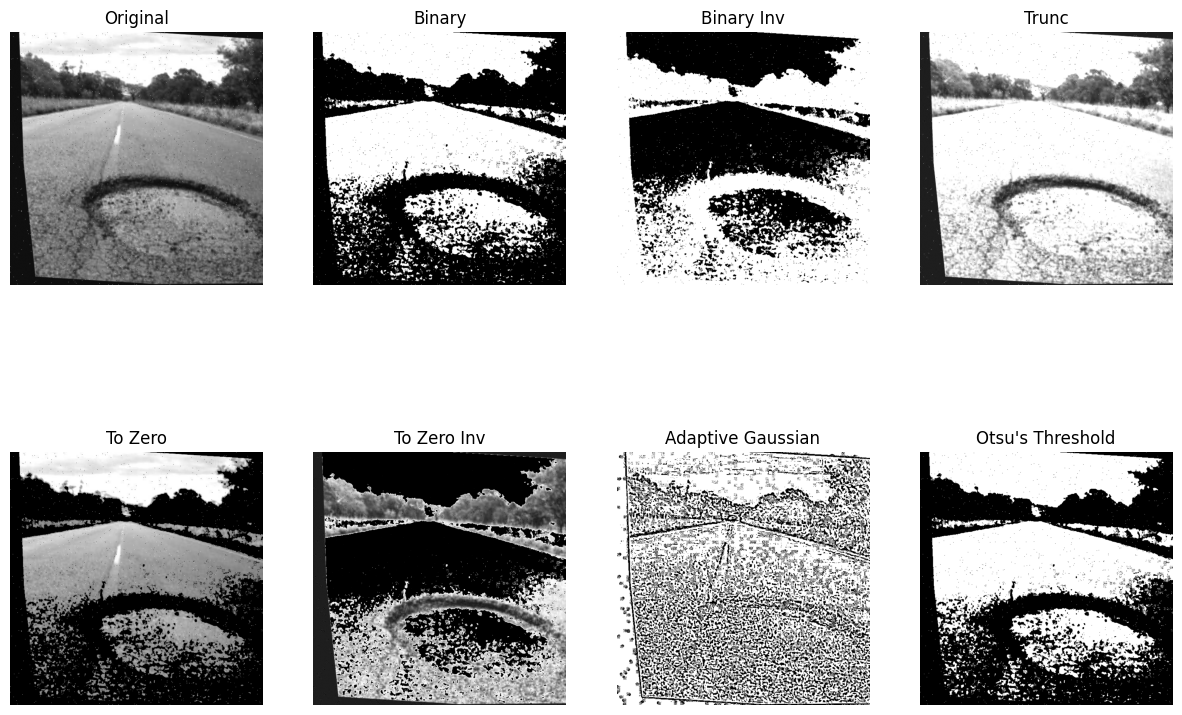

In [11]:
# Thresholding

img = cv2.imread('train_369.jpg', cv2.IMREAD_GRAYSCALE)

# (src Img, thresholdValue, maxVal, type)
# maxVal = nilai yang diberikan kalau kondisi terpenuhi
_, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
_, th2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
_, th3 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
_, th4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
_, th5 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)
th6 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 2)
# (srcImg, maxVal, adaptiveMethod, typeThreshold, blockSize, C)
# blockSize -> kernel size, harus ganjil = 9 -> 9 x 9
# C = threshold = adaptiveMethodReslut - C

ret_otsu, th7 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) 
# thres = 0 karena otsu yang kalkulasi secara otomatis
print("Otsu's threshold value:", ret_otsu)

# Display thresholded images
result_img = [img, th1, th2, th3, th4, th5, th6, th7]
result_titles = ['Original', 'Binary', 'Binary Inv', 'Trunc', 'To Zero', 'To Zero Inv', 'Adaptive Gaussian', "Otsu's Threshold"]
plt.figure(figsize=(15, 10))
for i in range(8):
    plt.subplot(2, 4, i+1)
    if i == 0:
        plt.imshow(result_img[i], cmap='gray')
    else:
        plt.imshow(result_img[i], cmap='gray')
    plt.title(result_titles[i])
    plt.axis('off')
plt.show()

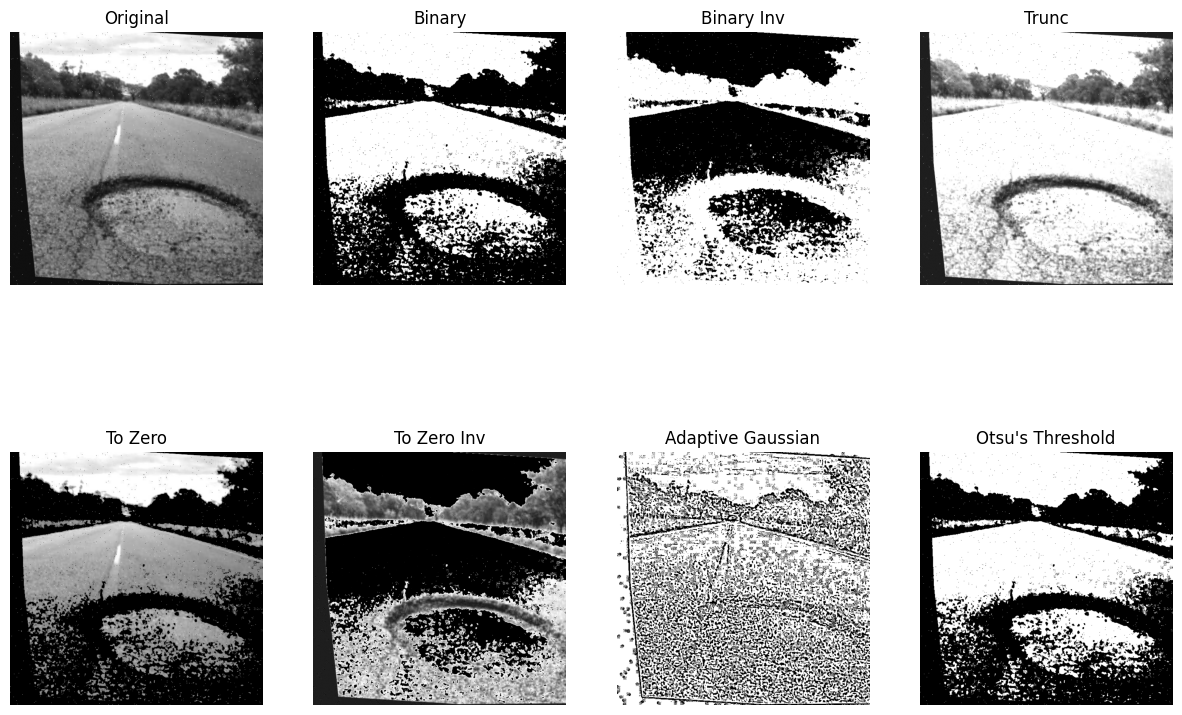

In [12]:
plt.figure(figsize=(15, 10))
for idx, (img, title) in enumerate(zip(result_img, result_titles)):
    plt.subplot(2, 4, idx+1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    
plt.show()